In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df = df.drop(columns=['Cabin', 'Ticket', 'Name'])

print(df.shape)
print(df.head())

(891, 10)
   PassengerId  Survived  Pclass     Sex   Age  SibSp  Parch     Fare  \
0            1         0       3    male  22.0      1      0   7.2500   
1            2         1       1  female  38.0      1      0  71.2833   
2            3         1       3  female  26.0      0      0   7.9250   
3            4         1       1  female  35.0      1      0  53.1000   
4            5         0       3    male  35.0      0      0   8.0500   

  Embarked  FamilySize  
0        S           2  
1        C           2  
2        S           1  
3        S           2  
4        S           1  


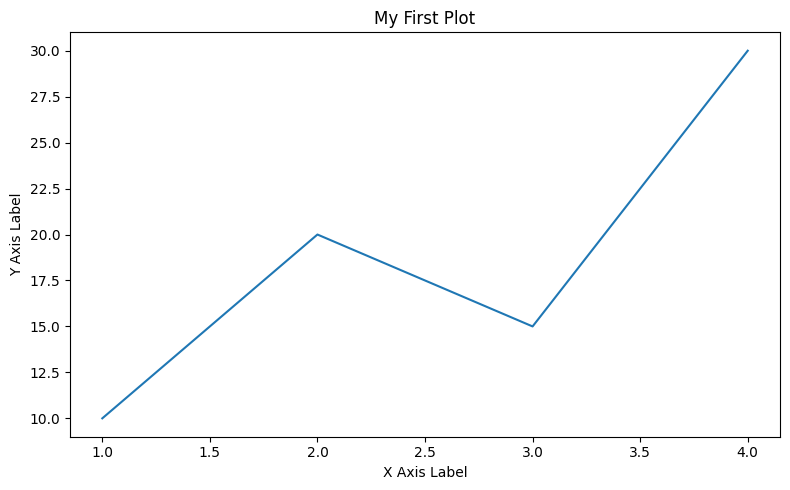

In [9]:
# Every matplotlib plot follows this structure
fig, ax = plt.subplots(figsize=(8, 5))  

#ax.plot([1, 2, 3, 4, 5, 6], [10, 15, 20, 25, 30, 35])  
ax.plot([1, 2, 3, 4], [10, 20, 15, 30])  
ax.set_title("My First Plot")             
ax.set_xlabel("X Axis Label")             
ax.set_ylabel("Y Axis Label")

plt.tight_layout()                    
plt.show()

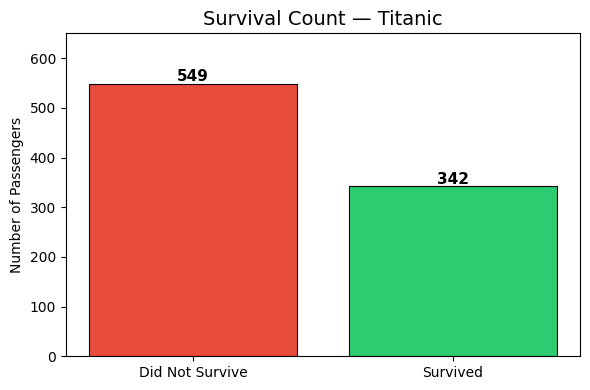

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

survival_counts = df['Survived'].value_counts()
bars = ax.bar(['Did Not Survive', 'Survived'], 
               survival_counts.values,
               color=['#e74c3c', '#2ecc71'],
               edgecolor='black',
               linewidth=0.8)

# Add count labels on top of bars
for bar, count in zip(bars, survival_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 5,
            str(count), 
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Survival Count — Titanic', fontsize=14)
ax.set_ylabel('Number of Passengers')
ax.set_ylim(0, 650)

plt.tight_layout()
plt.show()

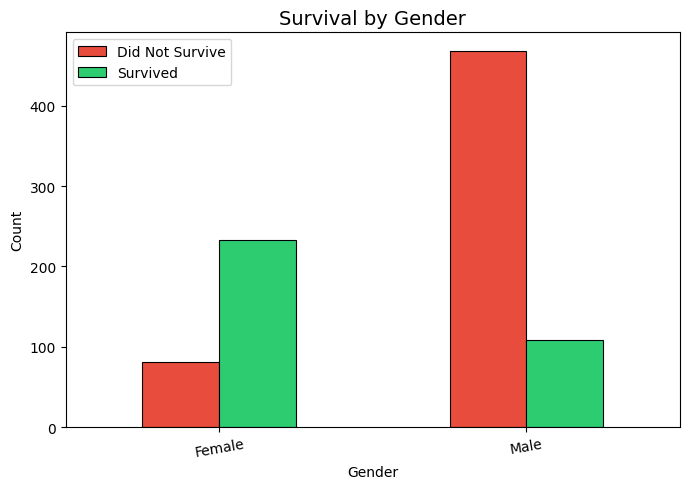

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

gender_survival = df.groupby(['Sex', 'Survived']).size().unstack()
gender_survival.plot(kind='bar', 
                     ax=ax,
                     color=['#e74c3c', '#2ecc71'],
                     edgecolor='black',
                     linewidth=0.8)

ax.set_title('Survival by Gender', fontsize=14)
ax.set_xlabel('Gender')
ax.set_ylabel('Count')
ax.set_xticklabels(['Female', 'Male'], rotation=10)
ax.legend(['Did Not Survive', 'Survived'])

plt.tight_layout()
plt.show()

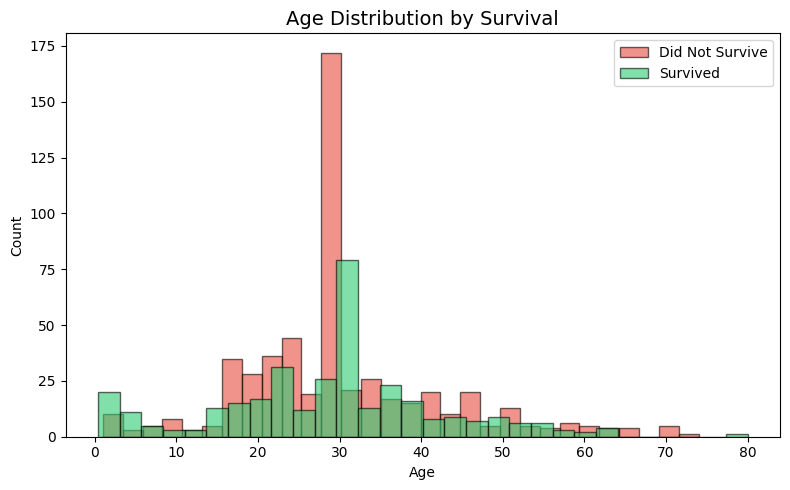

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

# Separate survivors and non-survivors
survivors = df[df['Survived'] == 1]['Age']
non_survivors = df[df['Survived'] == 0]['Age']

ax.hist(non_survivors, bins=30, alpha=0.6, 
        color='#e74c3c', label='Did Not Survive', edgecolor='black')
ax.hist(survivors, bins=30, alpha=0.6, 
        color='#2ecc71', label='Survived', edgecolor='black')

ax.set_title('Age Distribution by Survival', fontsize=14)
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.legend()

plt.tight_layout()
plt.show()

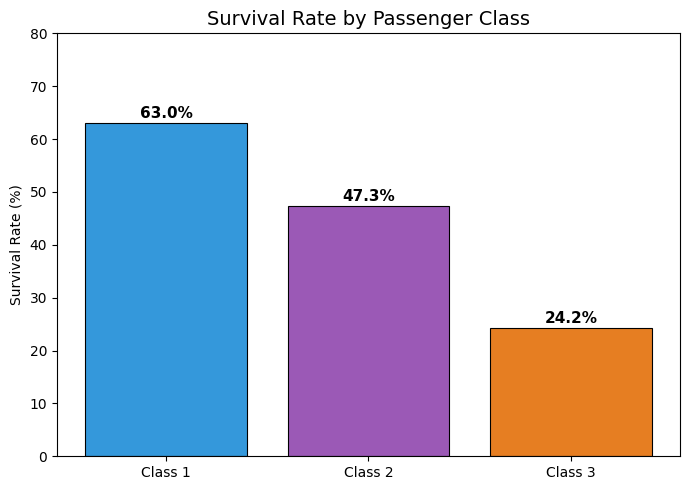

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))

class_survival = df.groupby('Pclass')['Survived'].mean() * 100

bars = ax.bar(['Class 1', 'Class 2', 'Class 3'],
               class_survival.values,
               color=['#3498db', '#9b59b6', '#e67e22'],
               edgecolor='black',
               linewidth=0.8)

for bar, val in zip(bars, class_survival.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{val:.1f}%',
            ha='center', fontsize=11, fontweight='bold')

ax.set_title('Survival Rate by Passenger Class', fontsize=14)
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 80)

plt.tight_layout()
plt.show()

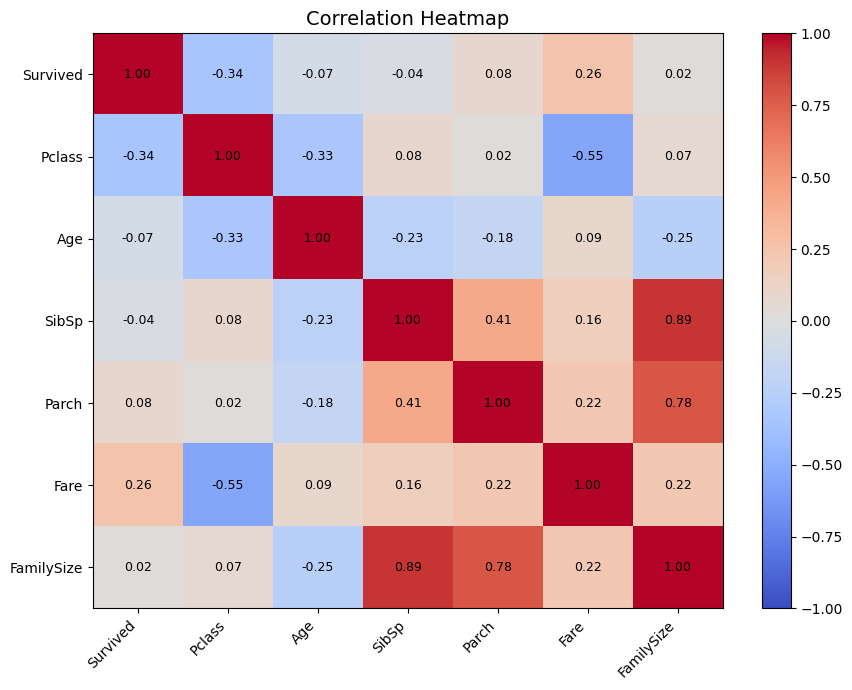

In [17]:
fig, ax = plt.subplots(figsize=(9, 7))

# Select only numerical columns
numerical_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']]

# Calculate correlation matrix
corr_matrix = numerical_df.corr()

# Plot heatmap manually with matplotlib
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

plt.colorbar(im, ax=ax)

columns = corr_matrix.columns.tolist()
ax.set_xticks(range(len(columns)))
ax.set_yticks(range(len(columns)))
ax.set_xticklabels(columns, rotation=45, ha='right')
ax.set_yticklabels(columns)

for i in range(len(columns)):
    for j in range(len(columns)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='black')

ax.set_title('Correlation Heatmap', fontsize=14)

plt.tight_layout()
plt.show()

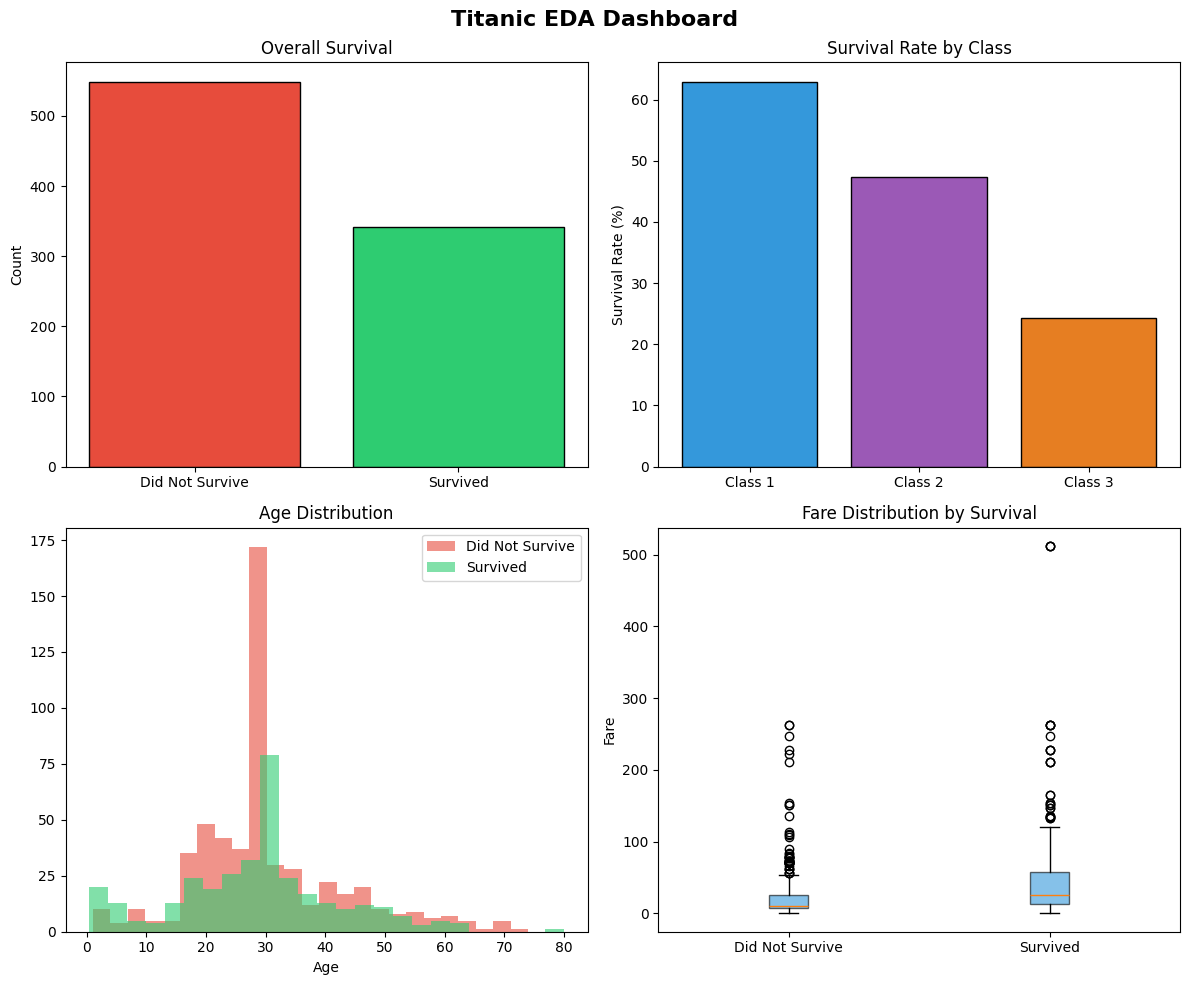

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Titanic EDA Dashboard', fontsize=16, fontweight='bold')

# Plot 1 — Survival count
survival_counts = df['Survived'].value_counts()
axes[0,0].bar(['Did Not Survive', 'Survived'], survival_counts.values,
               color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0,0].set_title('Overall Survival')
axes[0,0].set_ylabel('Count')

# Plot 2 — Survival rate by class
class_survival = df.groupby('Pclass')['Survived'].mean() * 100
axes[0,1].bar(['Class 1', 'Class 2', 'Class 3'], class_survival.values,
               color=['#3498db', '#9b59b6', '#e67e22'], edgecolor='black')
axes[0,1].set_title('Survival Rate by Class')
axes[0,1].set_ylabel('Survival Rate (%)')

# Plot 3 — Age distribution
axes[1,0].hist(df[df['Survived']==0]['Age'], bins=25, alpha=0.6,
                color='#e74c3c', label='Did Not Survive')
axes[1,0].hist(df[df['Survived']==1]['Age'], bins=25, alpha=0.6,
                color='#2ecc71', label='Survived')
axes[1,0].set_title('Age Distribution')
axes[1,0].set_xlabel('Age')
axes[1,0].legend()

# Plot 4 — Fare distribution by survival
axes[1,1].boxplot([df[df['Survived']==0]['Fare'],
                    df[df['Survived']==1]['Fare']],
                   tick_labels=['Did Not Survive', 'Survived'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1,1].set_title('Fare Distribution by Survival')
axes[1,1].set_ylabel('Fare')

plt.tight_layout()
plt.show()

In [1]:
#Exercise

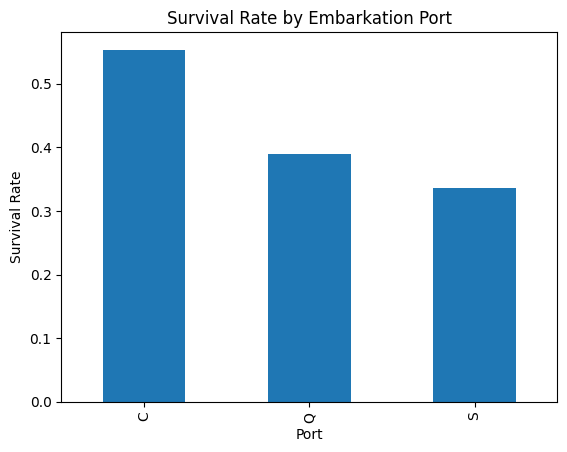

Highest survival port: C


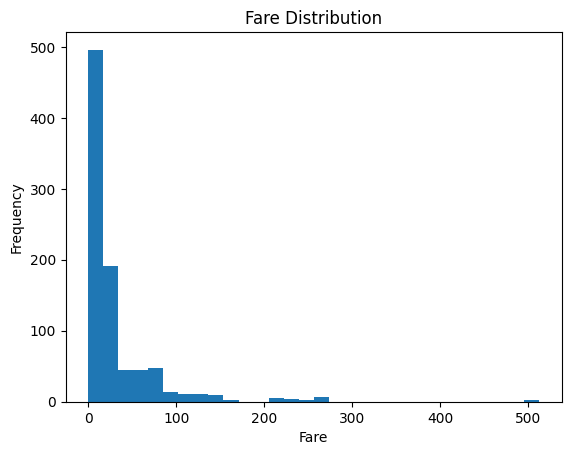

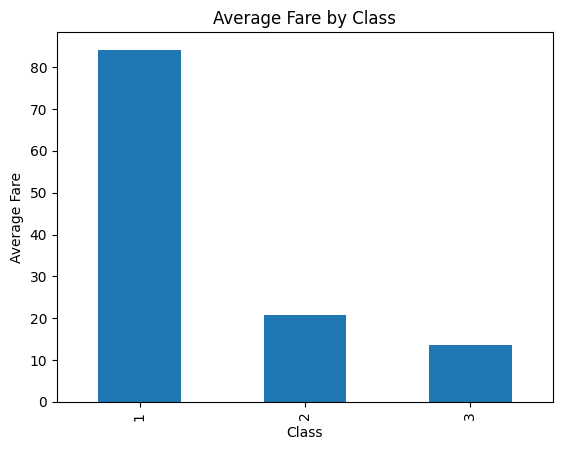

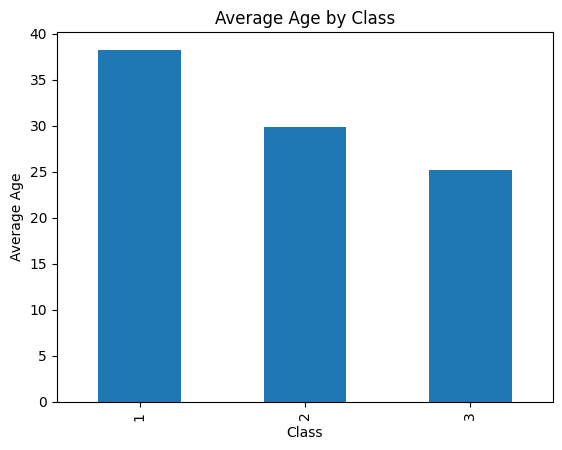


Strongest positive correlation: Fare
Strongest negative correlation: Pclass

Correlation between Pclass and Fare: -0.5494996199439076


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df["FamilySize"] = df["SibSp"] + df["Parch"] + 1


survival_by_port = df.groupby("Embarked")["Survived"].mean()

survival_by_port.plot(kind="bar")
plt.xlabel("Port")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Embarkation Port")
plt.show()

print("Highest survival port:", survival_by_port.idxmax())

df["Fare"].plot(kind="hist", bins=30)
plt.xlabel("Fare")
plt.title("Fare Distribution")
plt.show()

avg_fare = df.groupby("Pclass")["Fare"].mean()

avg_fare.plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Average Fare")
plt.title("Average Fare by Class")
plt.show()


avg_age = df.groupby("Pclass")["Age"].mean()

avg_age.plot(kind="bar")
plt.xlabel("Class")
plt.ylabel("Average Age")
plt.title("Average Age by Class")
plt.show()

# =================================================
corr = df.select_dtypes("number").corr()

surv_corr = corr["Survived"].drop("Survived")

print("\nStrongest positive correlation:", surv_corr.idxmax())
print("Strongest negative correlation:", surv_corr.idxmin())

print("\nCorrelation between Pclass and Fare:", corr.loc["Pclass", "Fare"])

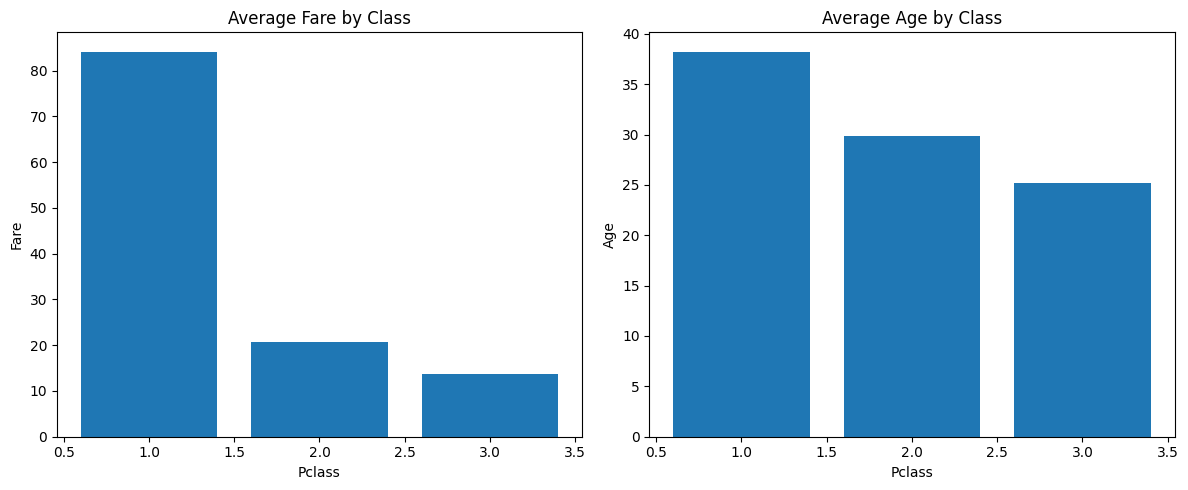

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)


# averages
avg_fare = df.groupby("Pclass")["Fare"].mean()
avg_age  = df.groupby("Pclass")["Age"].mean()

# ---- REQUIRED subplot structure ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# left plot
axes[0].bar(avg_fare.index, avg_fare.values)
axes[0].set_title("Average Fare by Class")
axes[0].set_xlabel("Pclass")
axes[0].set_ylabel("Fare")

# right plot
axes[1].bar(avg_age.index, avg_age.values)
axes[1].set_title("Average Age by Class")
axes[1].set_xlabel("Pclass")
axes[1].set_ylabel("Age")

plt.tight_layout()
plt.show()